In [1]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation.metrics import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
!ls ../artifacts/models/

level_09_daily_store_dept_sales_artifact.pkl


In [5]:
ARTIFACT = "level_09_daily_store_dept_sales_artifact"

In [6]:
import joblib

from scripts.train_datasets import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

# El artifact es liviano (sin datos): X_test/y_test/train/test se reconstruyen acá
# desde data/datasets/ (make build-datasets), repitiendo el split de train_datasets.py.
X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-08-26 21:10:14.118 | INFO     | scripts.train_datasets:load_data:137 - level_09_daily_store_dept | target=sales | 135,870 filas | 174 features (9 categóricas)
2026-08-26 21:10:14.200 | INFO     | src.data.split:log_summary:46 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 131,950 rows)
2026-08-26 21:10:14.201 | INFO     | src.data.split:log_summary:47 - Valid : 2016-03-28 to 2016-04-24 (28 days, 1,960 rows)
2026-08-26 21:10:14.201 | INFO     | src.data.split:log_summary:48 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)


KeyError: 'series_id'

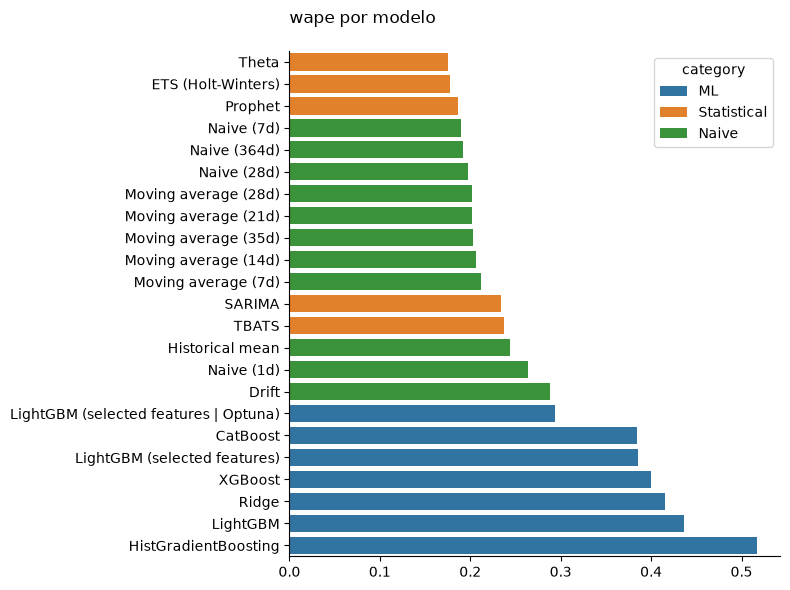

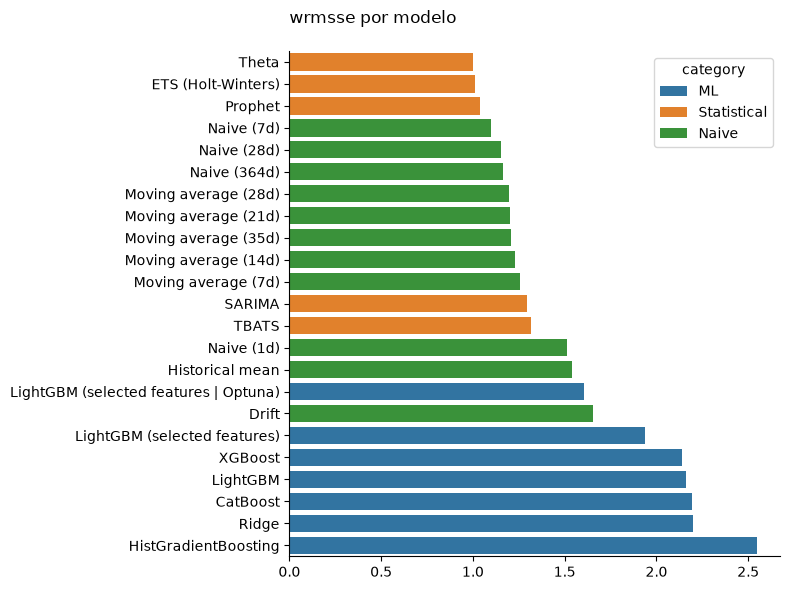

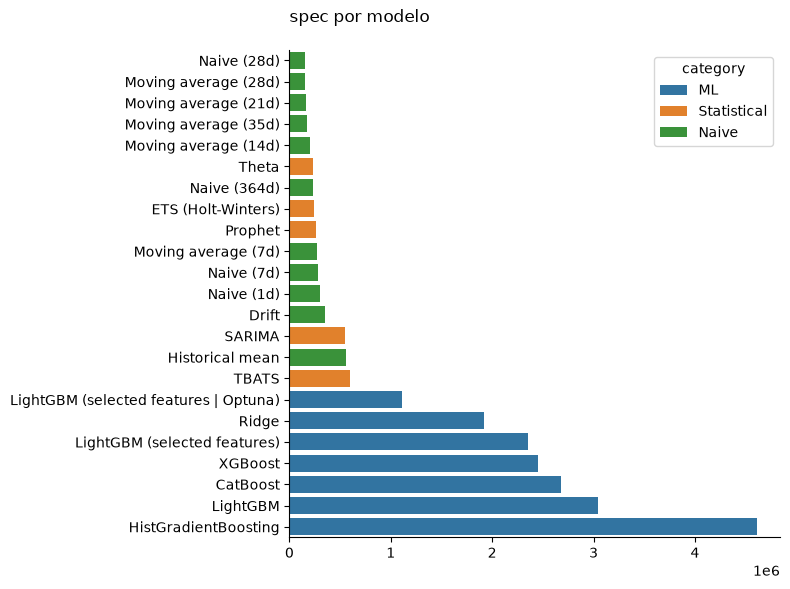

In [ ]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                 feature  mean_abs_shap
33                  lag1      95.715309
27  days_to_thanksgiving      69.890657
60                 lag28      57.589741
39                  lag7      44.639525
0                dept_id      37.072140
..                   ...            ...
16       days_to_closure       0.206106
17      event_type_1_enc       0.183325
30           pct_zero_28       0.125594
5           event_type_1       0.097753
31           pct_zero_90       0.032537

[133 rows x 2 columns]


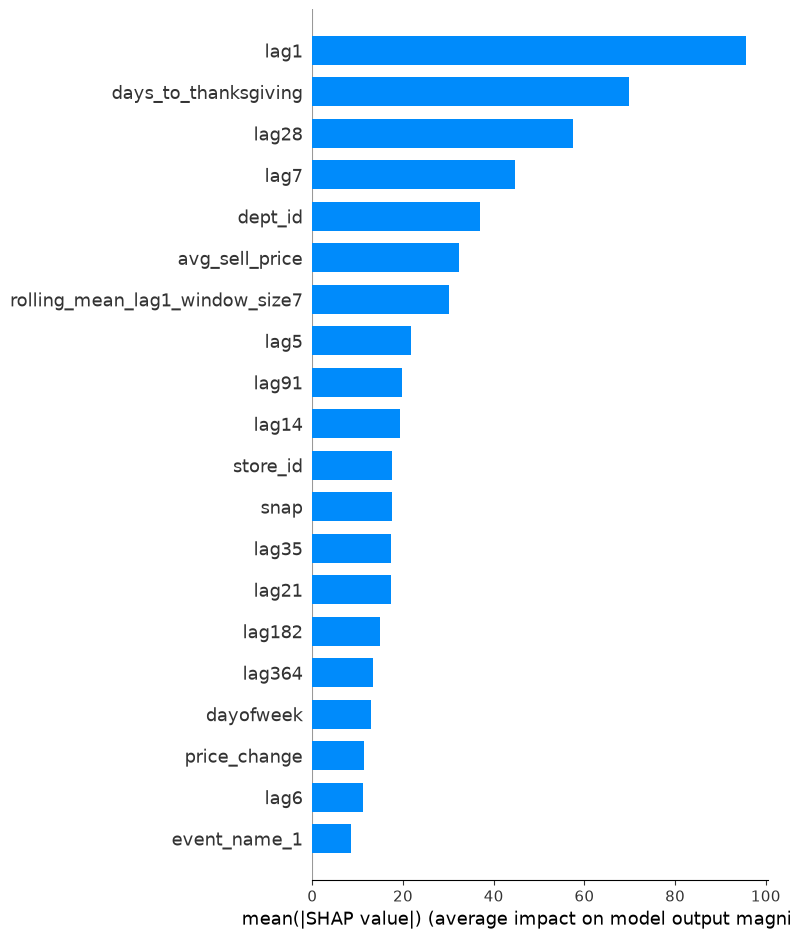

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


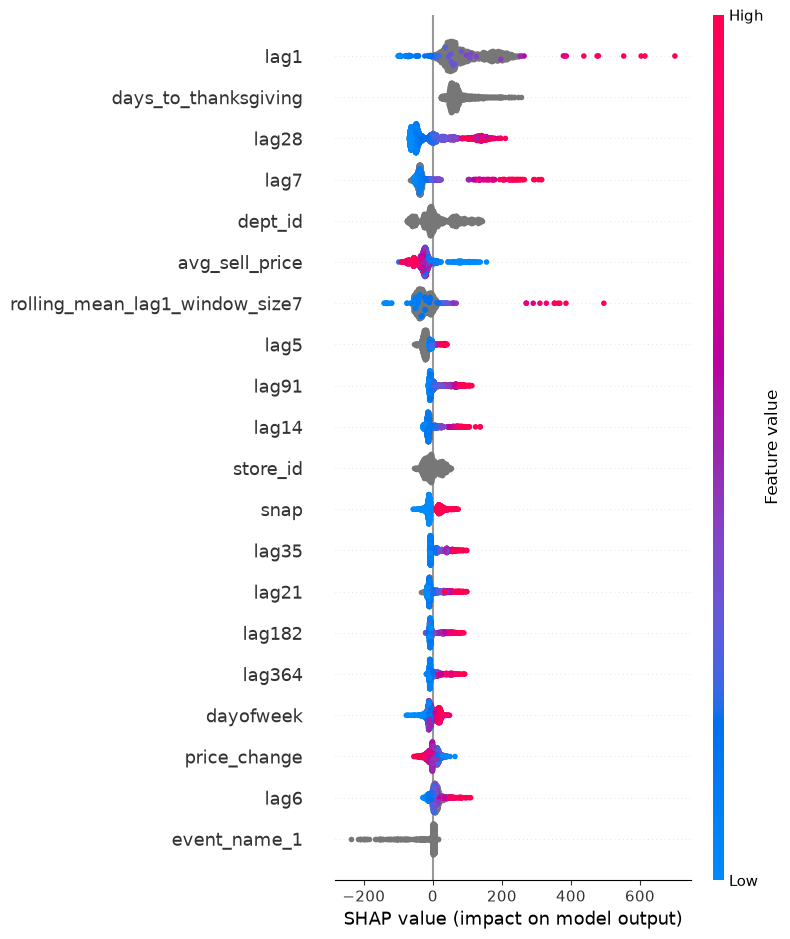

In [ ]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [ ]:
from src.evaluation import analizar_prediccion, plot_forecast, explain_prediction

In [ ]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 33.17%
Test WRMSSE: 1.8695


In [ ]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])

df_metrics.to_clipboard()

In [ ]:
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,28,28,77367.0,43427.0,33940.0,33940.0,194847.031250,0.049948,0.438688,-0.438688,0.644177,28.000000,2.758850,3.248531,49534.205357
FOODS_3_FOODS_CA_1_CA,28,28,65999.0,43800.0,22199.0,23183.0,167972.828125,0.043059,0.351263,-0.336354,0.502635,26.811543,2.268459,2.264040,22136.705357
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,28,28,38478.0,37550.0,928.0,5776.0,163889.625000,0.042012,0.150112,-0.024118,0.191011,4.498615,1.296611,1.339945,254.830357
FOODS_3_FOODS_WI_2_WI,28,28,67991.0,38797.0,29194.0,29800.0,154892.234375,0.039706,0.438293,-0.429380,0.629895,27.430604,3.387492,3.743381,42110.330357
FOODS_3_FOODS_CA_2_CA,28,28,57132.0,38647.0,18485.0,19805.0,146760.937500,0.037622,0.346653,-0.323549,0.492452,26.133805,3.339299,3.346896,16460.821429


In [ ]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_CA_4_CA,28,28,10468.0,10260.0,208.0,1132.0,40467.789062,0.010374,0.108139,-0.019870,0.137692,5.144876,0.678399,0.703185,48.508929
FOODS_2_FOODS_WI_3_WI,28,28,16734.0,17391.0,-657.0,1935.0,56782.070312,0.014556,0.115633,0.039261,0.159297,-9.506977,0.700757,0.758956,172.464286
FOODS_1_FOODS_CA_1_CA,28,28,9587.0,10412.0,-825.0,1443.0,24644.589844,0.006318,0.150516,0.086054,0.173061,-16.008316,0.777210,0.929524,96.901786
HOBBIES_1_HOBBIES_TX_3_TX,28,28,9856.0,9949.0,-93.0,1261.0,67694.507812,0.017353,0.127942,0.009436,0.169330,-2.065028,0.801090,0.870321,25.116071
HOBBIES_1_HOBBIES_TX_2_TX,28,28,10183.0,11412.0,-1229.0,1719.0,56965.871094,0.014603,0.168811,0.120691,0.195769,-20.018615,0.820950,0.941726,291.125000


In [ ]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_CA_4_CA,28,28,10468.0,10260.0,208.0,1132.0,40467.789062,0.010374,0.108139,-0.019870,0.137692,5.144876,0.678399,0.703185,48.508929
FOODS_2_FOODS_WI_3_WI,28,28,16734.0,17391.0,-657.0,1935.0,56782.070312,0.014556,0.115633,0.039261,0.159297,-9.506977,0.700757,0.758956,172.464286
FOODS_1_FOODS_CA_1_CA,28,28,9587.0,10412.0,-825.0,1443.0,24644.589844,0.006318,0.150516,0.086054,0.173061,-16.008316,0.777210,0.929524,96.901786
HOBBIES_1_HOBBIES_TX_3_TX,28,28,9856.0,9949.0,-93.0,1261.0,67694.507812,0.017353,0.127942,0.009436,0.169330,-2.065028,0.801090,0.870321,25.116071
HOBBIES_1_HOBBIES_TX_2_TX,28,28,10183.0,11412.0,-1229.0,1719.0,56965.871094,0.014603,0.168811,0.120691,0.195769,-20.018615,0.820950,0.941726,291.125000


In [ ]:
CASES = ['HOUSEHOLD_1_HOUSEHOLD_TX_3_TX', 'HOBBIES_1_HOBBIES_WI_1_WI','HOUSEHOLD_2_HOUSEHOLD_CA_2_CA']

df_metrics.to_clipboard(decimal=",", sep="\t")

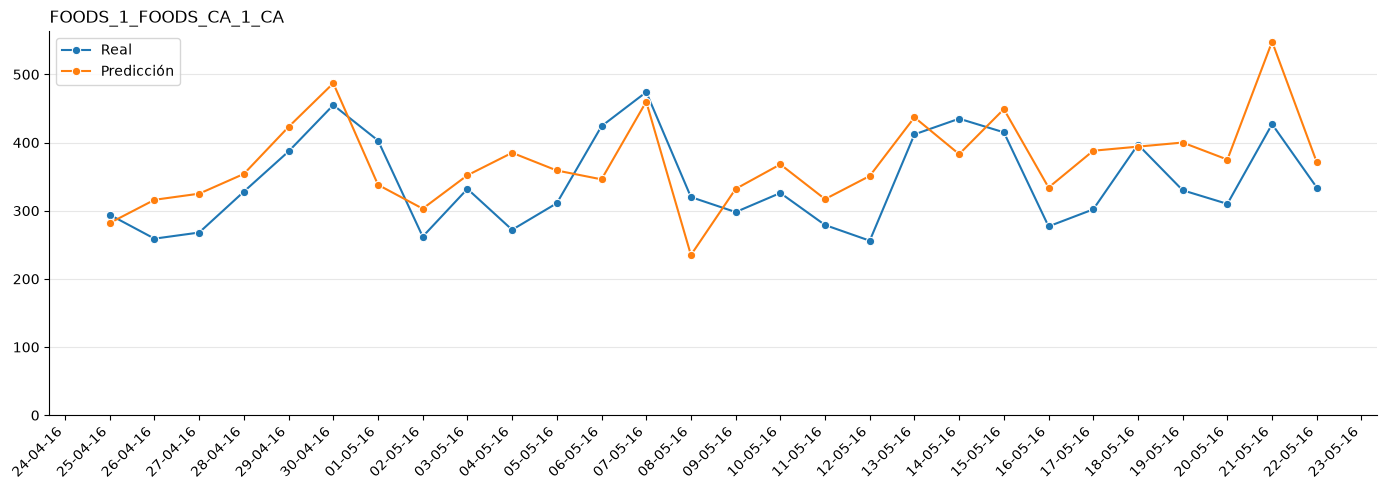

################################################## Date: 2016-05-18 00:00:00 ##################################################


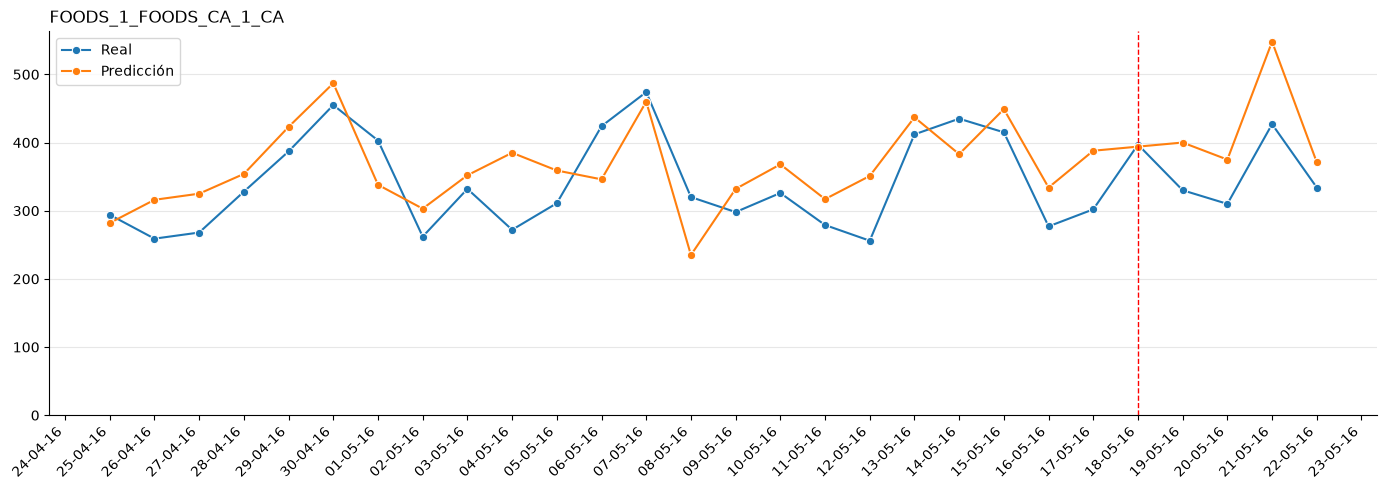

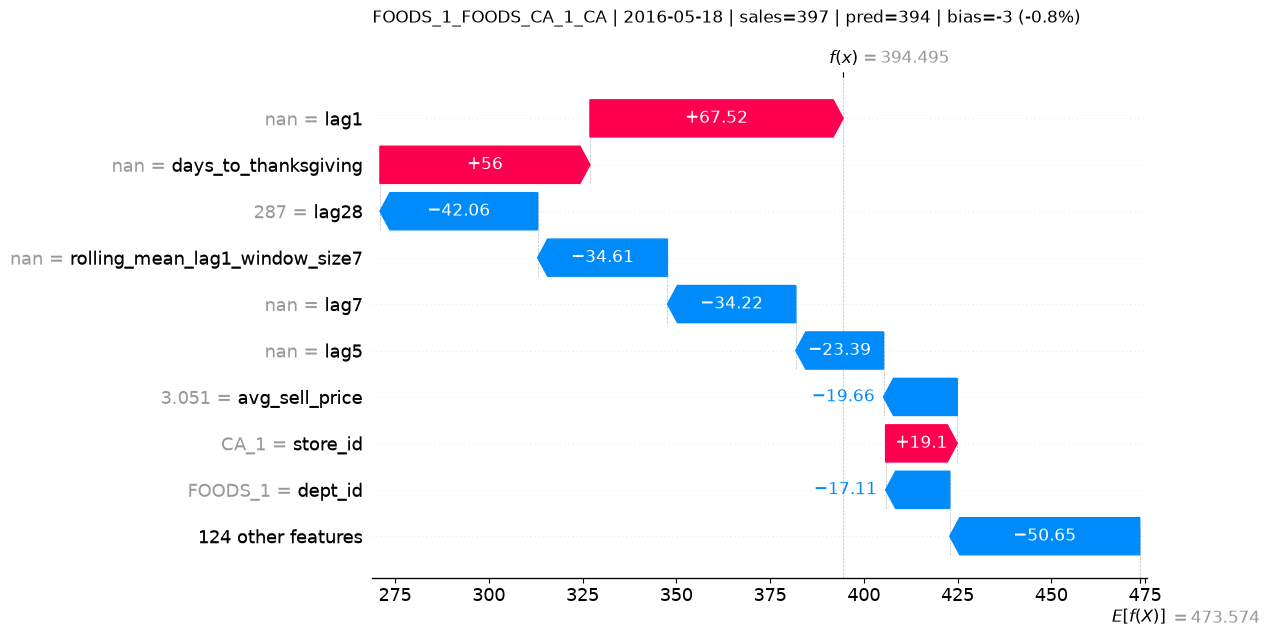

################################################## Date: 2016-05-07 00:00:00 ##################################################


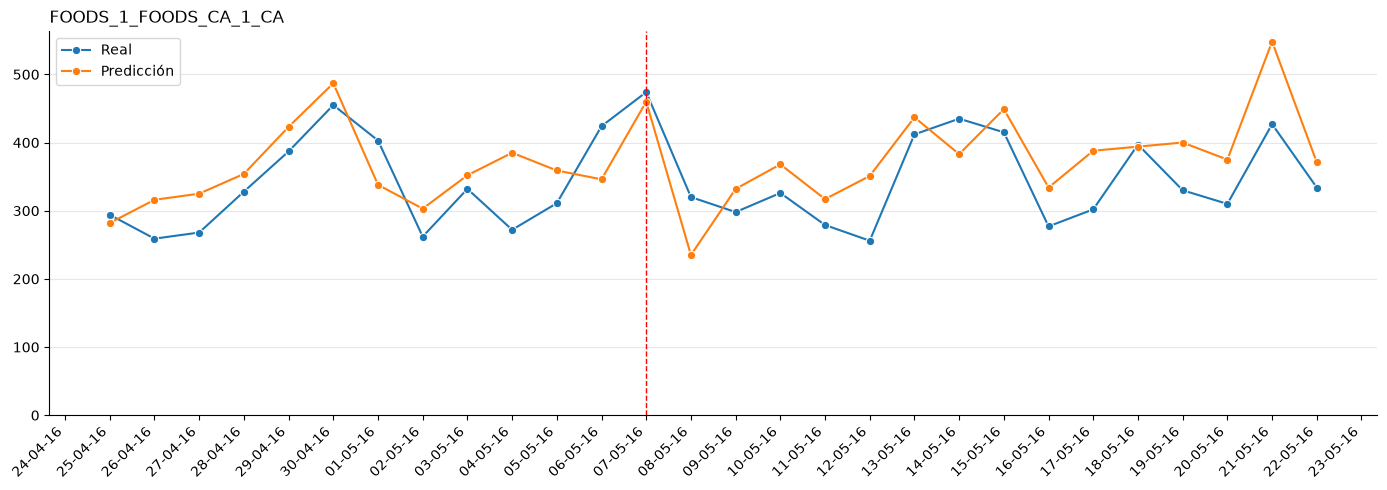

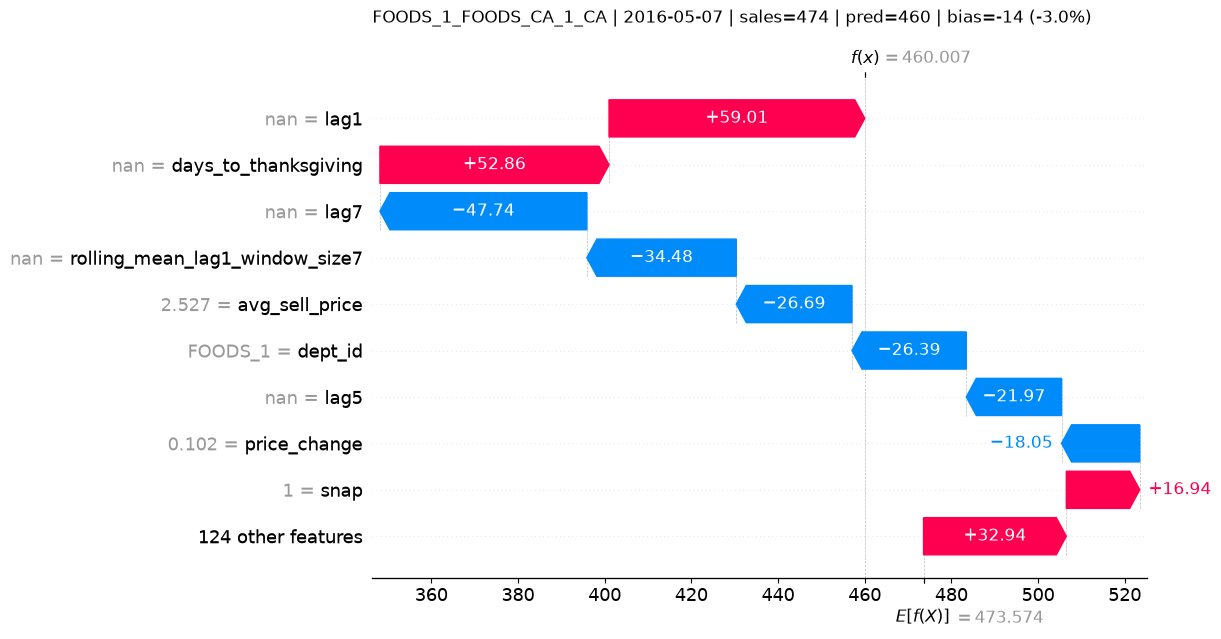

################################################## Date: 2016-04-25 00:00:00 ##################################################


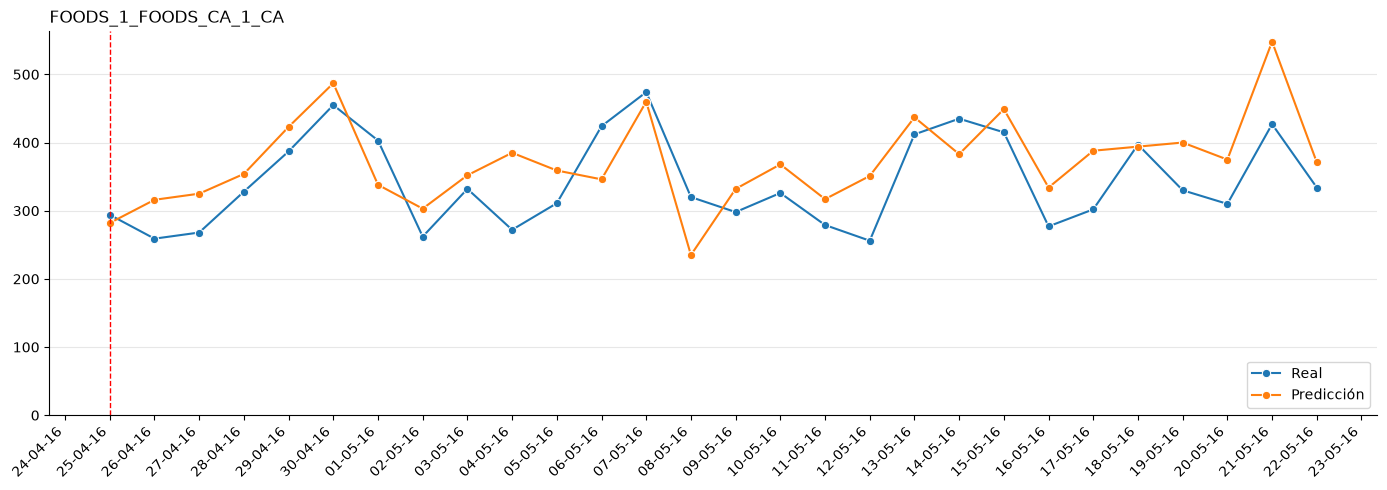

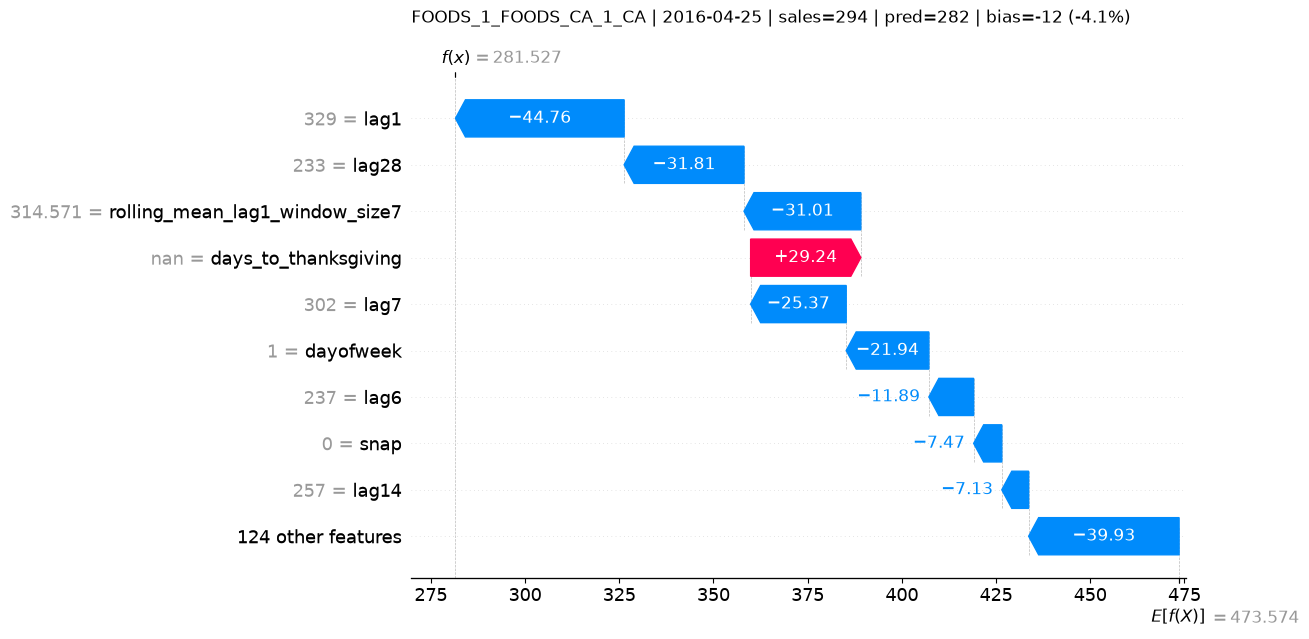

################################################## Date: 2016-05-04 00:00:00 ##################################################


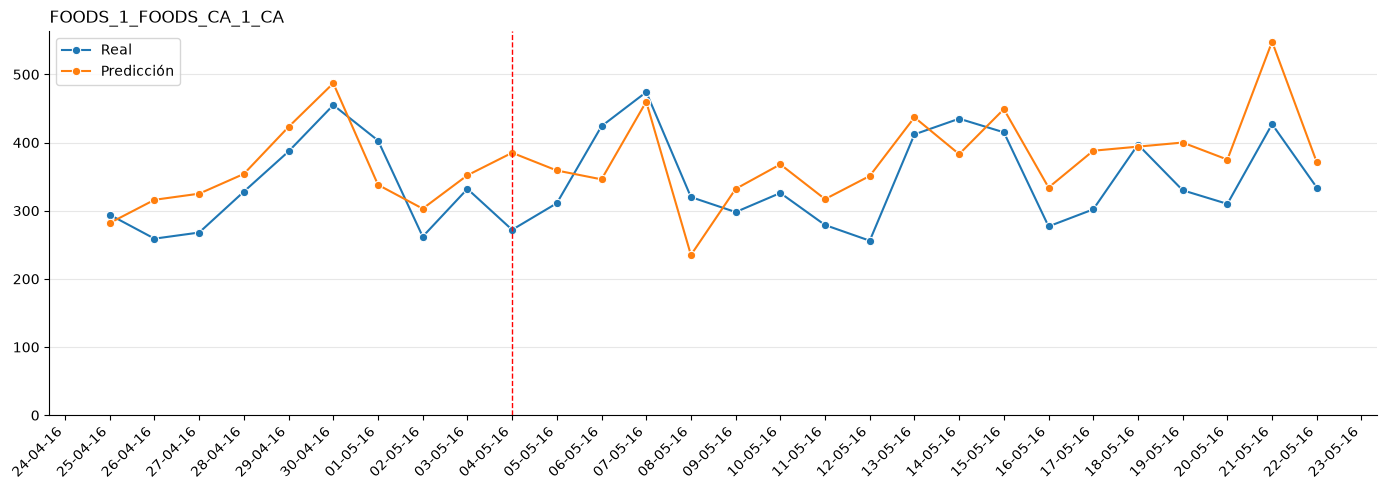

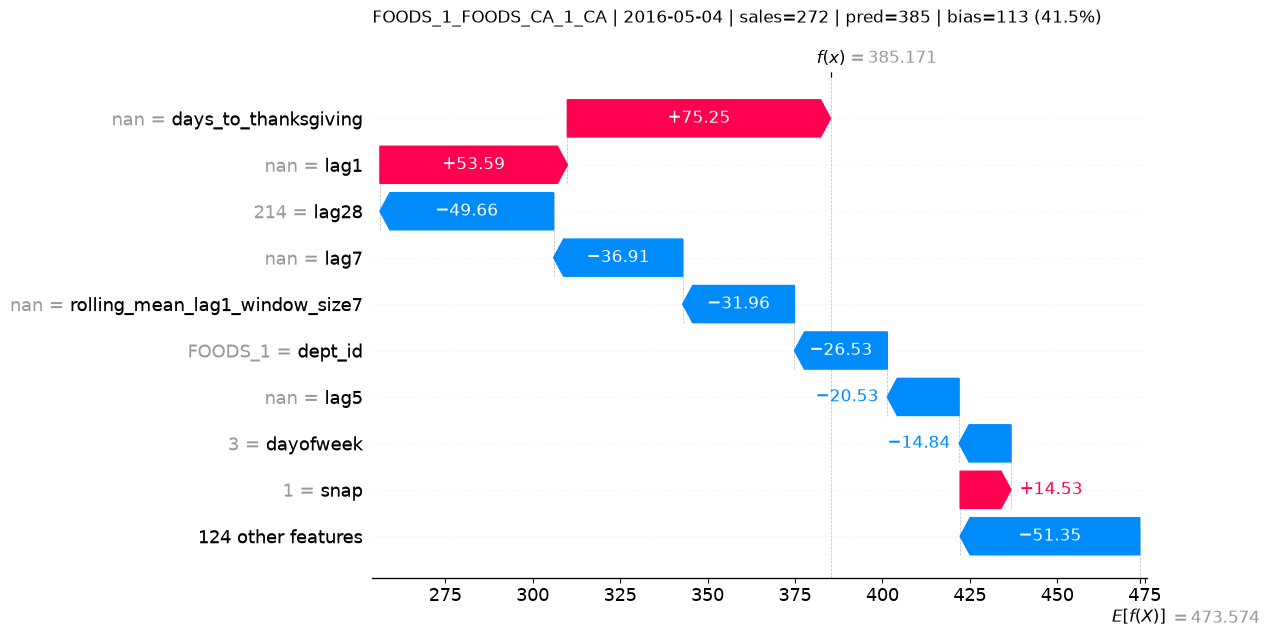

################################################## Date: 2016-05-12 00:00:00 ##################################################


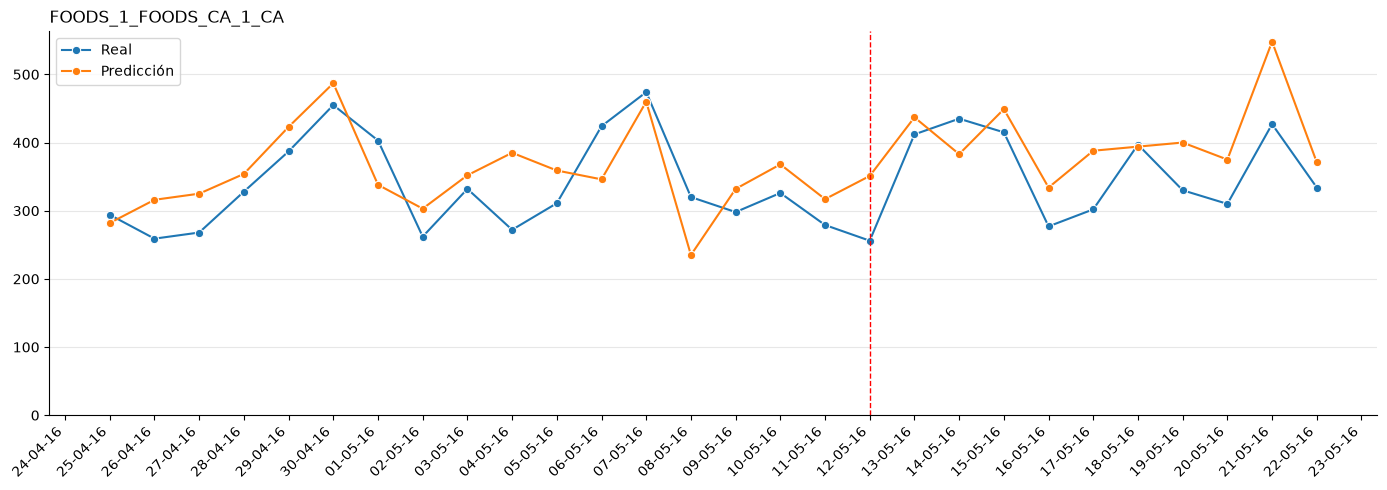

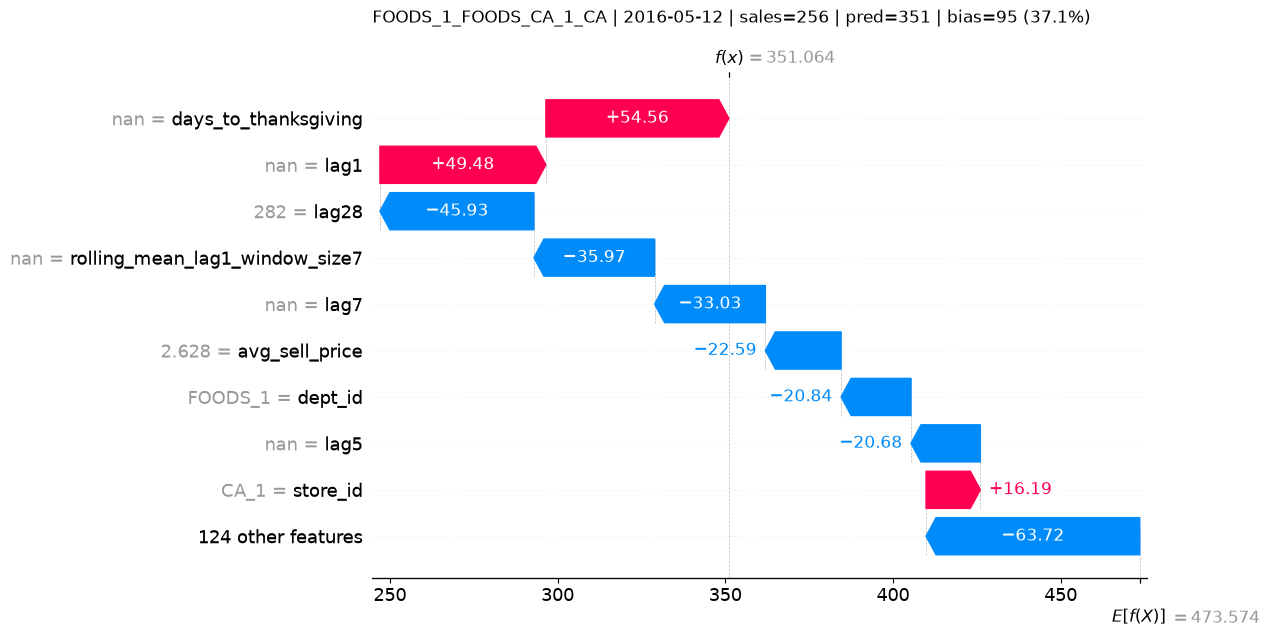

################################################## Date: 2016-05-17 00:00:00 ##################################################


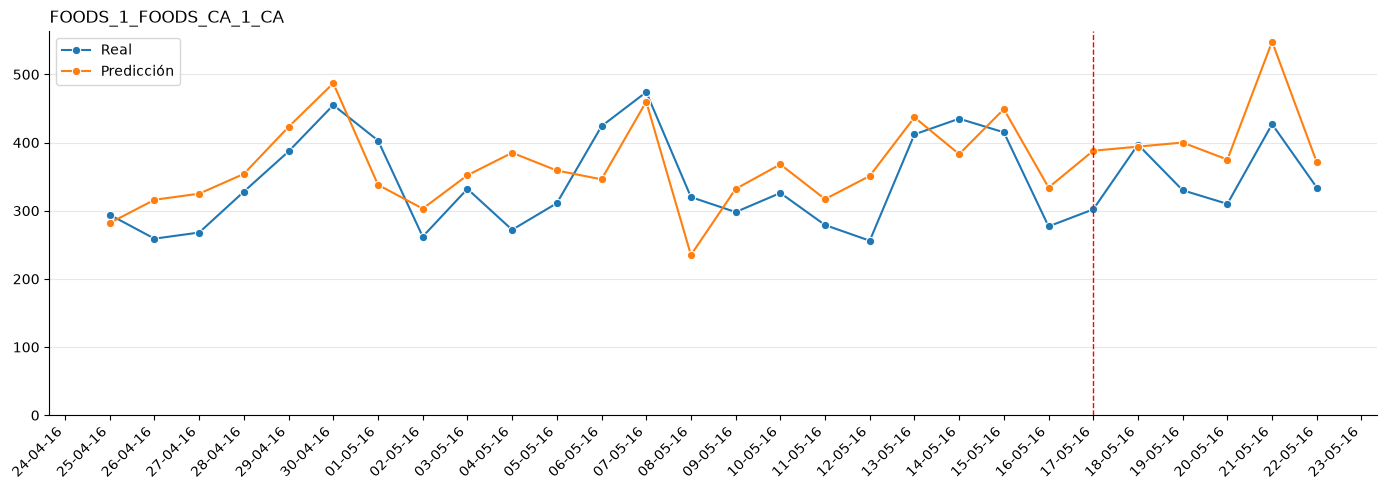

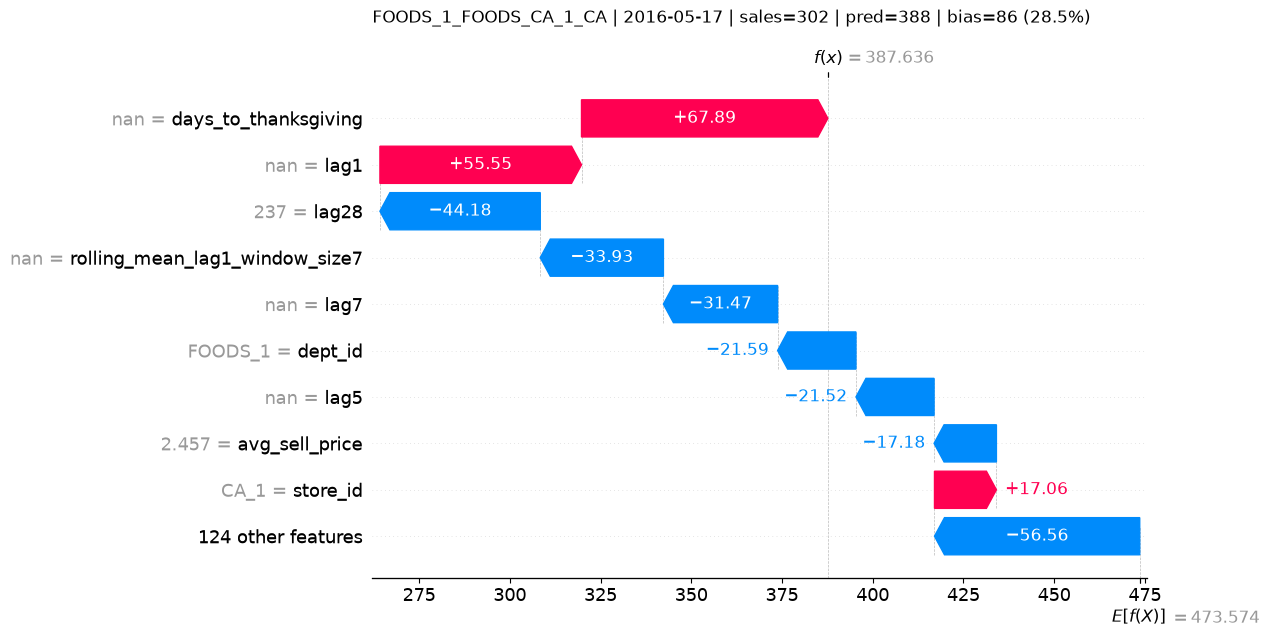

In [ ]:
AGG_ID = 'FOODS_1_FOODS_CA_1_CA'

top_best_dates = df_pred.query(f'series_id == "{AGG_ID}"').nsmallest(3, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{AGG_ID}"').nlargest(3, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=AGG_ID)

for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=AGG_ID, explainer=explainer, date=i)

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=AGG_ID, explainer=explainer, date=i)